In [1]:
# Exploratory Data Analysis

# In this notebook, I load the `sample.csv` artifact from Weights & Biases, inspect the dataset, perform basic data quality checks, and apply simple cleaning steps. Missing values are not imputed in this notebook.

In [2]:
#imports + load artifact:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

run = wandb.init(project="nyc_airbnb", entity="gardner-lingjia-cariad", group="eda", save_code=True)
local_path = run.use_artifact("gardner-lingjia-cariad/nyc_airbnb/sample.csv:latest").file()
df = pd.read_csv(local_path)
df.head()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/lingjia/.netrc.
wandb: Currently logged in as: gardner-lingjia (gardner-lingjia-cariad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
## Initial inspection

#First, I inspect the structure of the dataset, data types, summary statistics, and missing values.

In [4]:
df.shape

(48895, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
## Duplicate check

#I check whether the dataset contains duplicated rows.

In [9]:
df.duplicated().sum()

0

In [10]:
## Target variable inspection

#I inspect the distribution of the target variable `price` to identify possible outliers.

In [11]:

df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

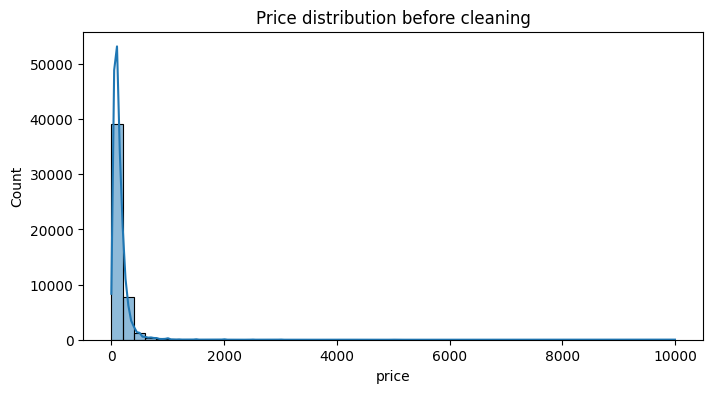

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price distribution before cleaning")
plt.show()

In [13]:
## Cleaning steps

#I remove price outliers and convert the `last_review` column to datetime format. I do not impute missing values.


In [14]:
# Drop outliers
min_price = 10
max_price = 350
idx = df['price'].between(min_price, max_price)
df = df[idx].copy()

df['last_review'] = pd.to_datetime(df['last_review'])

In [15]:
## Cleaned data check

#Finally, I inspect the cleaned dataset. Some missing values remain, which is expected because missing-value imputation is not part of this notebook.


In [16]:
df.shape


(46428, 16)

In [17]:
df.info()



<class 'pandas.core.frame.DataFrame'>
Int64Index: 46428 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              46428 non-null  int64         
 1   name                            46413 non-null  object        
 2   host_id                         46428 non-null  int64         
 3   host_name                       46407 non-null  object        
 4   neighbourhood_group             46428 non-null  object        
 5   neighbourhood                   46428 non-null  object        
 6   latitude                        46428 non-null  float64       
 7   longitude                       46428 non-null  float64       
 8   room_type                       46428 non-null  object        
 9   price                           46428 non-null  int64         
 10  minimum_nights                  46428 non-null  int64         
 11  nu

In [18]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.642800e+04,4.642800e+04,46428.000000,46428.000000,46428.000000,46428.000000,46428.000000,37246.000000,46428.000000,46428.000000
mean,1.891808e+07,6.645101e+07,40.728572,-73.950968,122.538016,6.943181,23.827712,1.377473,6.672504,109.676854
std,1.093120e+07,7.769127e+07,0.055190,0.046386,71.862581,19.877510,45.190521,1.690493,31.083436,130.413952
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.445461e+06,7.719136e+06,40.689360,-73.982100,65.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.954462e+07,3.032152e+07,40.722010,-73.954570,100.000000,2.000000,5.000000,0.715000,1.000000,40.000000
75%,2.893777e+07,1.056405e+08,40.763330,-73.934628,160.000000,5.000000,24.000000,2.020000,2.000000,217.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,350.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [19]:
df.isnull().sum()

id                                   0
name                                15
host_id                              0
host_name                           21
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9182
reviews_per_month                 9182
calculated_host_listings_count       0
availability_365                     0
dtype: int64

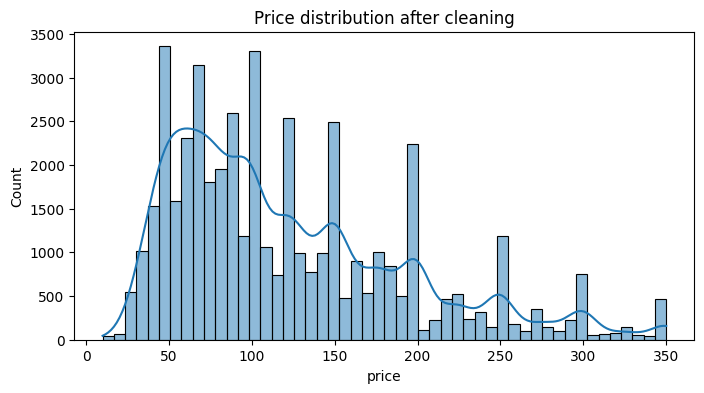

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price distribution after cleaning")
plt.show()

In [21]:
run.finish()